In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

In [ ]:
file_path = 'Station5-cleaned-merged-data.csv'
data = pd.read_csv(file_path)
full_data = data.copy()
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
print(data.describe())

              SWC_5        SWC_10        SWC_20        SWC_50           T_5  \
count  57586.000000  57586.000000  57586.000000  57586.000000  57586.000000   
mean       0.377005      0.339038      0.351628      0.316463      0.449795   
std        0.196708      0.188265      0.222565      0.218775      0.193541   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.207547      0.177570      0.134228      0.104938      0.298780   
50%        0.354717      0.331776      0.355705      0.265432      0.449797   
75%        0.539623      0.495327      0.536913      0.512346      0.594715   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

               T_10          T_20          T_50          Tair            RH  \
count  57586.000000  57586.000000  57586.000000  57586.000000  57586.000000   
mean       0.495060      0.522264      0.567520      0.884982      0.821193   
std        0.208943      0.219305      0.239853    

In [ ]:
print("Missing values in each column: \n", data.isnull().sum())

Missing values in each column: 
 Date         0
SWC_5        0
SWC_10       0
SWC_20       0
SWC_50       0
T_5          0
T_10         0
T_20         0
T_50         0
Tair         0
RH           0
Srad         0
Ppt          0
Wx           0
Wy           0
Day sin      0
Day cos      0
Year sin     0
Year cos     0
Latitude     0
Longitude    0
dtype: int64


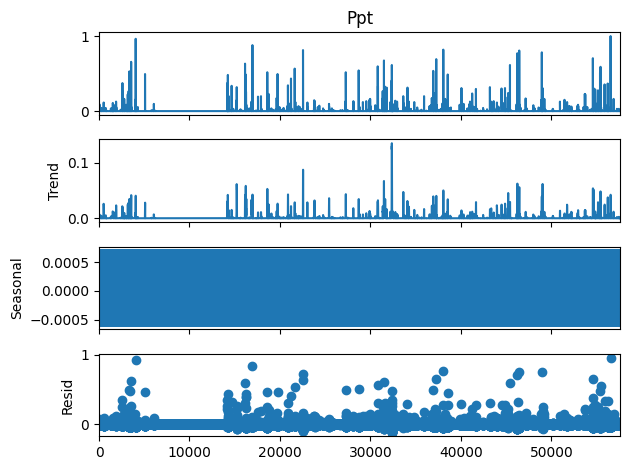

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
period = 24 #hourly data
# Perform the seasonal decomposition
decomposition = seasonal_decompose(data['Ppt'], model='additive', period=period)

# Plot the decomposed components
fig = decomposition.plot()
plt.show()

<Figure size 640x480 with 0 Axes>

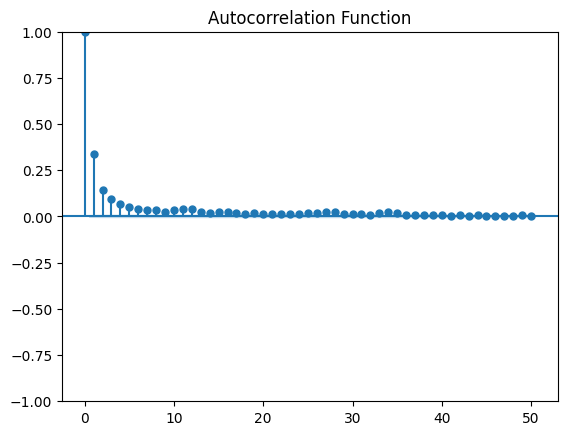

<Figure size 640x480 with 0 Axes>

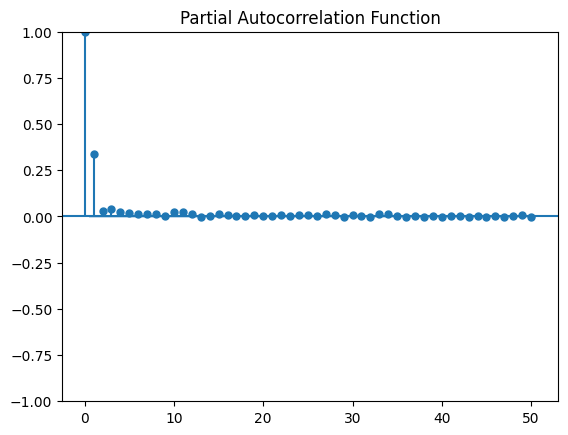

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Autocorrelation plot
plt.figure()
plot_acf(data['Ppt'], lags=50)
plt.title('Autocorrelation Function')

# Partial autocorrelation plot
plt.figure()
plot_pacf(data['Ppt'], lags=50)
plt.title('Partial Autocorrelation Function')

plt.show()

<ipython-input-8-9443fe70e1c3>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = full_data.corr()


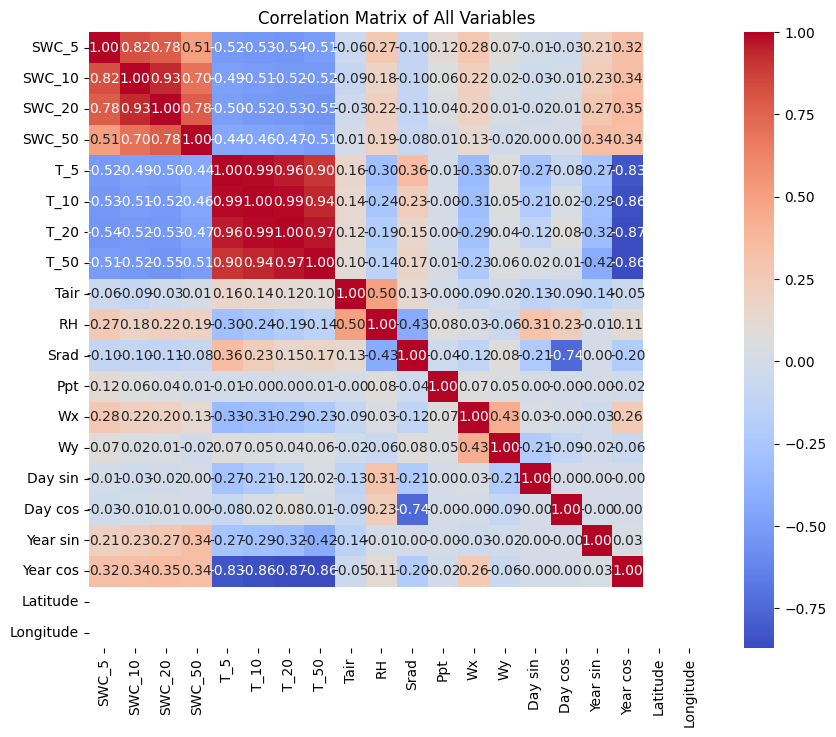

In [ ]:
corr_matrix = full_data.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix of All Variables')
plt.show()

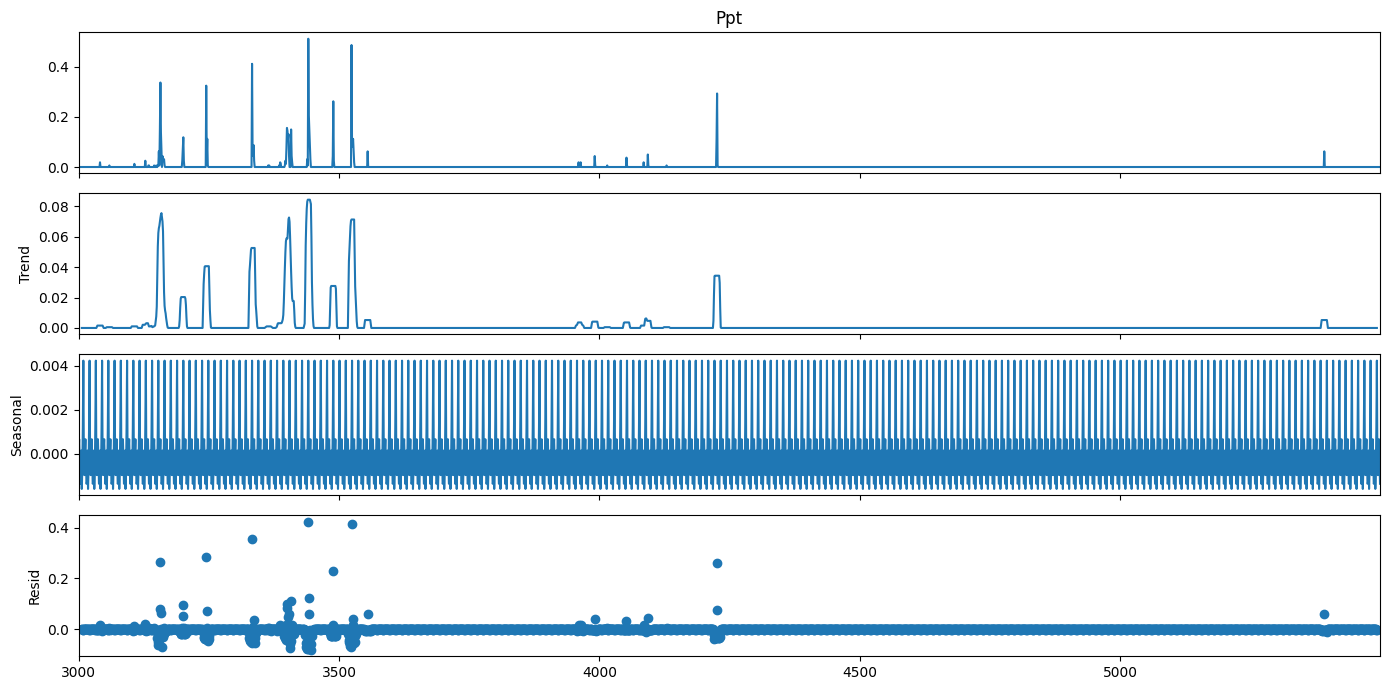

In [ ]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

data = data.iloc[3000:5500]

# Assuming 'data' is your DataFrame and it contains a 'ppt' column with precipitation data.
# Ensure that 'data' has a DateTimeIndex appropriate for the time series.

# Performing the seasonal decomposition
decomposition = seasonal_decompose(data['Ppt'], model='additive', period=12)

# Plotting the seasonal decomposition
plt.rcParams['figure.figsize'] = (14, 7)
decomposition.plot()
plt.tight_layout()
plt.savefig(f"seasonality.pdf", format='pdf')
plt.show()
